### **Numerical Solutions for a Double-Minimum Potential Well**
Naiara Enrique Mañas (1641063)

Comencem important les llibreries que utilitzarem

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Utilitzo els mateixos parametres trobats a https://chem.libretexts.org/Bookshelves/Physical_and_Theoretical_Chemistry_Textbook_Maps/Quantum_Tutorials_(Rioux)/09%3A_Numerical_Solutions_for_Schrodinger's_Equation/9.10%3A_Numerical_Solutions_for_a_Double-Minimum_Potential_Well

In [2]:
#Definim el potencial
def getV(x):
    b=1
    c=6
    potvalue = b*x**4-c*x**2
    return potvalue

Definim la funció que calculara la matriu

In [3]:
#Discretized Schrodinger equation in n points (FROM 0 to n-1)
def Eq(n,h,x):
    F = np.zeros([n,n])
    for i in range(0,n):
        F[i,i] = -2*((h**2)*getV(x[i]) + 1)
        if i > 0:
           F[i,i-1] = 1
           if i < n-1:
              F[i,i+1] = 1
    return F

Començarem a donar els resultats numerics

In [4]:
# Interval for calculating the wave function [-L/2,L/2] we want -4 to 4
L = 8
xlower = -L/2.0
xupper = L/2.0

#Discretization options
h = 0.02  #discretization in space

#Create coordinates at which the solution will be calculated
x = np.arange(xlower,xupper+h,h)
#grid size (how many discrete points to use in the range [-L/2,L/2])
npoints=len(x)

print("Using",npoints, "grid points.")

Using 401 grid points.


Ara calculem explicitament F i es diagonalitza. El resultats no els obtindrem ordenats per tant s'ha de fer.

In [5]:
#Calculation of discrete form of Schrodinger Equation and diagonalization
F=Eq(npoints,h,x)
eigenValues, eigenVectors = np.linalg.eig(F)

#Order results by eigenvalue
# w ordered eigenvalues and vs ordered eigenvectors
idx = eigenValues.argsort()[::-1]
w = eigenValues[idx]
vs = eigenVectors[:,idx]

#Energy Level
E = - w/(2.0*h**2)

Ara mostrem els 5 primers valors d'energia

In [6]:
#Energy Levels
E = - w/(2.0*h**2)
for k in range(0,5):
  print("n=",k,", E(numeric)=%.4f" %E[k])

n= 0 , E(numeric)=-6.6430
n= 1 , E(numeric)=-6.6409
n= 2 , E(numeric)=-2.4521
n= 3 , E(numeric)=-2.3166
n= 4 , E(numeric)=0.4143


  Ara mirem si els estats són degenerats AE=O o si hi ha efecte tunel E>0

In [7]:
AE10=E[1]-E[0]
print(AE10)

0.002100124283506588


Observem que el valor de la variació de E és molt petit, això ens diu que els nivells són quasi degenerats, pero hi ha una mica de efecte tunel.

Ara abans de graficar els valors de $\psi(x)$, graficarme el potencial

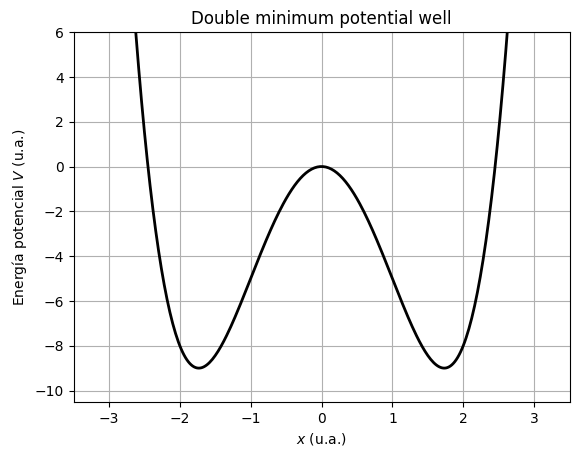

In [22]:
plt.plot(x, getV(x), color='black', lw=2, label='V(x)')

plt.title("Double minimum potential well")
plt.xlabel("$x$ (u.a.)")
plt.ylabel("Energía potencial $V$ (u.a.)")
plt.ylim(-10.5, 6)
plt.xlim(-3.5, 3.5)
plt.grid(True)
plt.show()

Ara graficarem els notres valors

Plotting


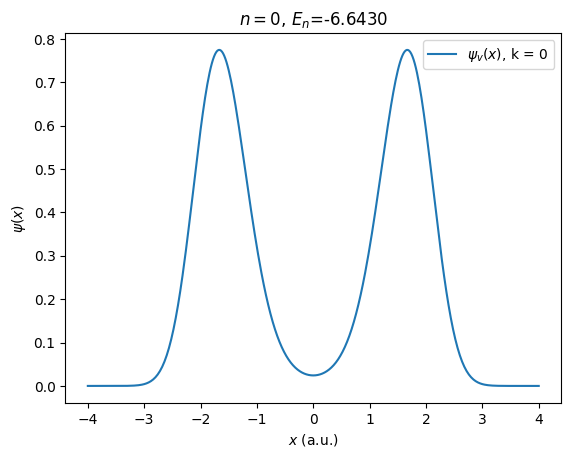

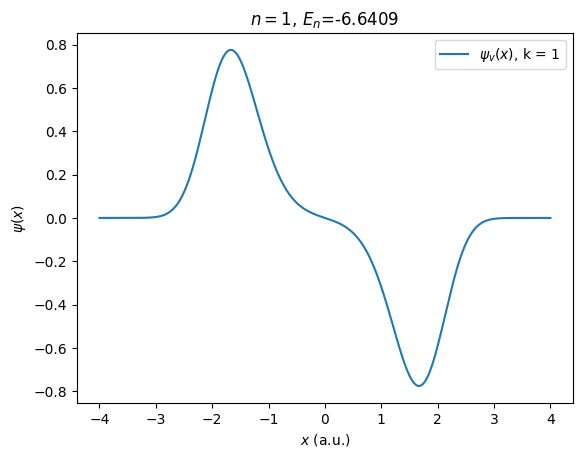

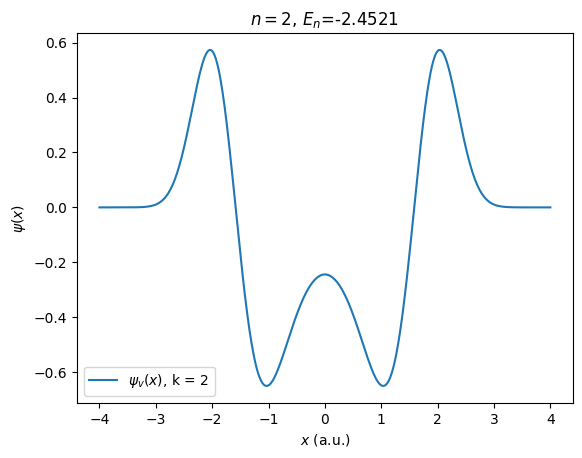

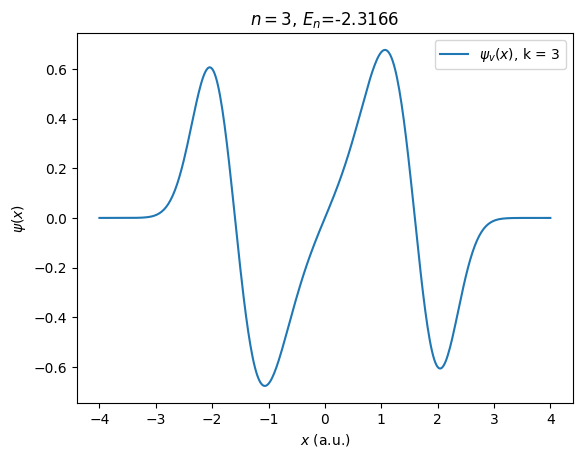

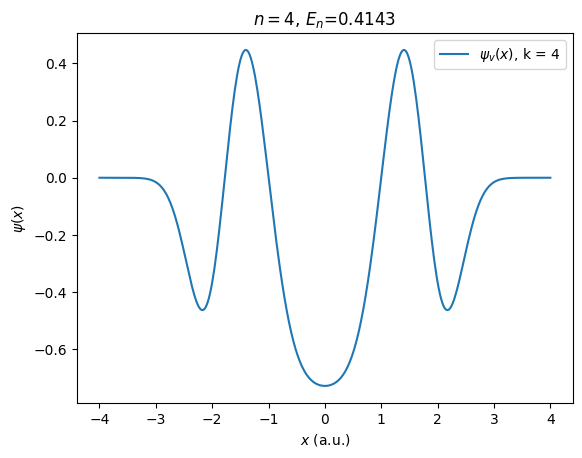

Bye


In [8]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,5):
	plt.plot(x,psi[v],label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)$')
	plt.show()

print("Bye")


Ara vull gràficar la densitat de probabilitat, o sigui $\psi(x)^2$ per a cada nivell

Plotting


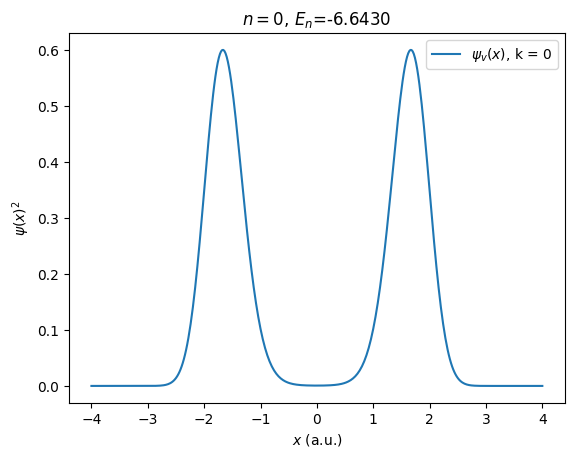

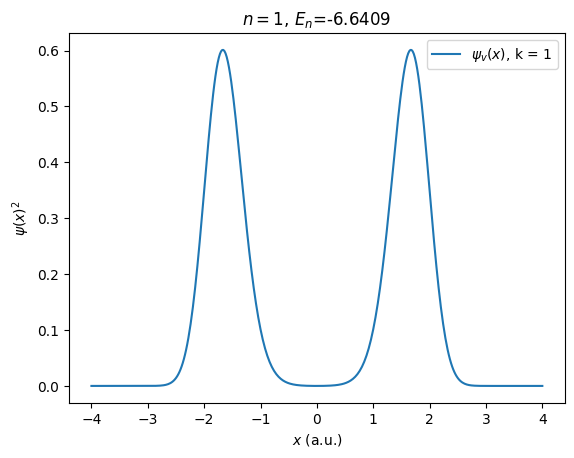

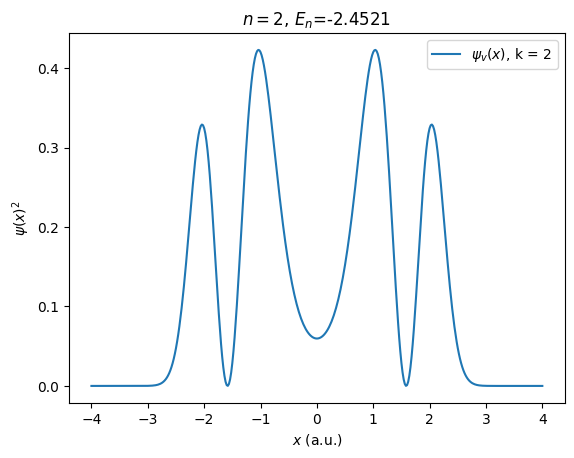

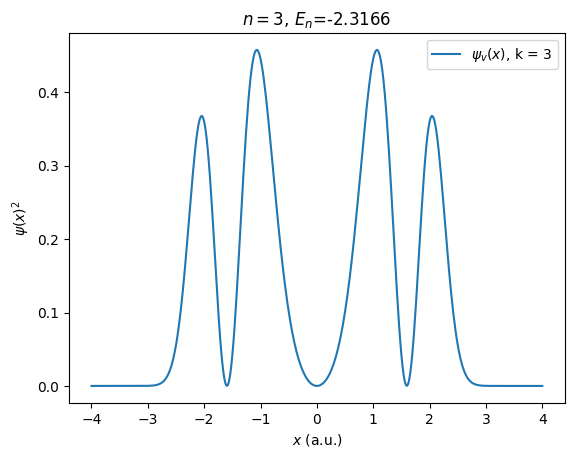

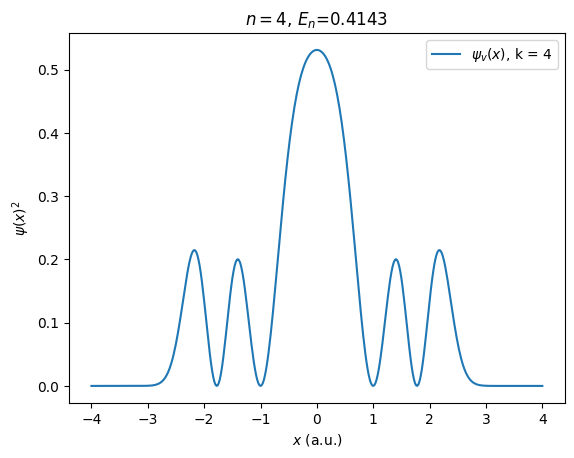

In [13]:
#Init Wavefunction (empty list with npoints elements)
psi = [None]*npoints

#Calculation of normalised Wave Functions
for k in range(0,len(w)):
	psi[k] = vs[:,k]
	integral = h*np.dot(psi[k],psi[k])
	psi[k] = psi[k]/integral**0.5

#Plot Wave functions
print("Plotting")

#v = int(input("\n Quantum Number (enter 0 for ground state):\n>"))
for v in range(0,5):
	plt.plot(x,(psi[v])**2,label=r'$\psi_v(x)$, k = ' + str(v))
	plt.title(r'$n=$'+ str(v) + r', $E_n$=' + '{:.4f}'.format(E[v]))
	plt.legend()
	plt.xlabel(r'$x$ (a.u.)')
	plt.ylabel(r'$\psi(x)^2$')
	plt.show()

Ara vull gràficar la densitat de probabilitat totes juntes, o sigui $\psi(x)^2$ per a cada nivell, juntament amb el potencial.

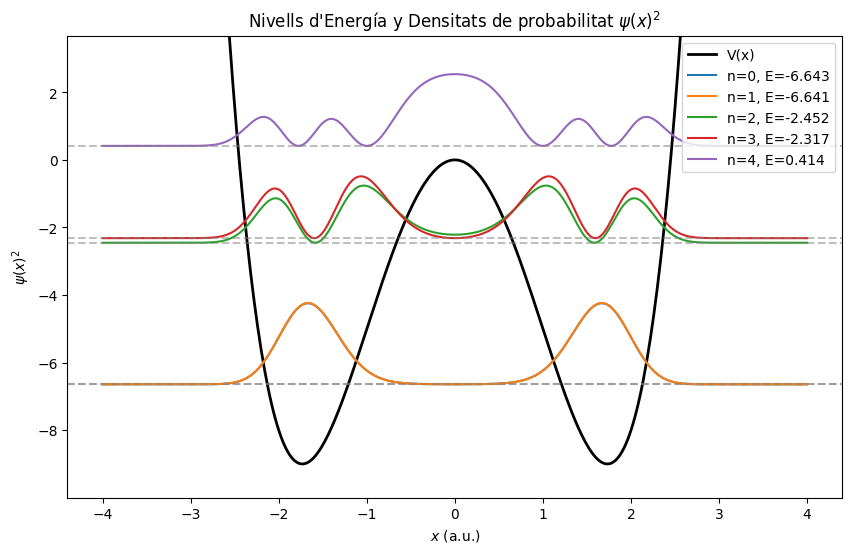

In [15]:
plt.figure(figsize=(10, 6))
# Grafiquem el potencial
plt.plot(x, getV(x), color='black', lw=2, label='V(x)')

# Graficarem les primeres 5 densitats de probabilitat
for v in range(5):
    plt.plot(x, ((psi[v] * 2))**2 + E[v], label=f'n={v}, E={E[v]:.3f}')
    plt.axhline(y=E[v], color='gray', linestyle='--', alpha=0.5)

plt.ylim(min(getV(x)) - 1, E[5] + 2) # Ajustar límites
plt.title(r"Nivells d'Energía y Densitats de probabilitat $\psi(x)^2$")
plt.xlabel(r'$x$ (a.u.)')
plt.ylabel(r'$\psi(x)^2$')
plt.legend()
plt.show()

**Canviem la discretització de l'espai**
Això ho farem per observar la precisió dels resultats segons com varia la discretització

**Valor amb el que hem fet la part anterior**

Per al valor de h=0.02 el que obtenim es aquests valors

![imatge.png](attachment:ca817a7b-954e-42fd-b537-e4dce2032d3b.png)

**Valors de discretització de l'espai més grans**

En posar h=0.03 obtenim aquests resultats. Observem que els primers dos decimals no varien, en canvi a partir d'aquests si varia el resultat

![imatge.png](attachment:d2b94233-26db-41fb-809a-40bbadcf6ac9.png)

En posar h=0.1. Observem que els primers dos decimals de les primeres dues energies no varien. en canvi  partir d'aquests ja varien els segons decimals. O sigui que els valors exactes serien els primer decimal

![imatge.png](attachment:bc4df07e-cc79-4c23-aeb8-3ebc75d69974.png)

**Valors de discretització de l'espai més petits**

En posar h=0.01 obtenim aquests resultats. Observem que els primers dos decimals no varien, en canvi a partir d'aquests si varia el resultat

![imatge.png](attachment:e35a5458-0ab9-4ce8-b6f2-a33e14e58b25.png)

En posar h=0.002. Observem que els calculs tomen molt més temps en fer-se. Observem que els primers dos decimas els mantenen iguals que en el cas de la pràctica.

![imatge.png](attachment:7da39076-eb58-4f17-97dd-00801b238d08.png)

**Conlcusións**
Observem que podem confiar en el nostre resultat fins als dos primers decimals. Després la precisió ja no es tan bona, i varia segons el valor de h.